# AI를 이용한 게임 불법 프로그램 탐지
팀명: Fairplay Fairy  
참여학생: 장지호(팀장), 강민영, 김선중, 설장헌, 정해성  
지도교수: 황호영

---

### 핵심 포인트

1.  **게임 이용자의 플레이 영상만을 사용**:
    * OpenCV를 사용하여 전처리
    * 위치 변화량, 속도, 가속도, 가가속도 등을 추출
2.  **AI 모델의 판별 근거를 설명하기 위해 SHAP 사용**:
    * 모델 투명성 확보
    * 판단의 시각적 근거 생성

## 라이브러리 설치

In [99]:
!pip install xgboost==3.0.5 shap pandas scikit-learn openpyxl xlsxwriter

In [100]:
import xgboost as xgb
import seaborn as sns
import pandas as pd
import numpy as np
import itertools
import joblib
import shap
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
from scipy.stats import entropy, randint, uniform
from google.colab import drive

In [101]:
drive.mount('/content/drive')

# JavaScript 시각화를 위해 초기화 (Colab에서 필수)
shap.initjs()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 모델 및 데이터 로드

In [102]:
# --- 불러올 모델의 경로 지정 ---
model_load_path = '/content/drive/MyDrive/Preprocessed_Dataset/xgboost_cheater_detection_model_demo.json'

# --- 모델 로드 ---
model = xgb.XGBClassifier()
model.load_model(model_load_path)

In [103]:
# --- 불러올 데이터의 경로 지정 ---
preprocessed_data_path = "/content/drive/MyDrive/Preprocessed_Dataset/preprocessed_data.xlsx"

# --- 엑셀 로드 ---
df = pd.read_excel(preprocessed_data_path)

## 데이터 전처리

In [104]:
# --- 특징 및 라벨 분리 ---
y_test_df = df['cheat'] # 'cheat' 열을 라벨로 사용
groups = df['filename'] # 데이터를 나눌 기준 (파일 이름)
non_feature_cols = ['filename', 'cheat', 'start_frame'] # 특징이 아닌 열들
X_test_df = df.drop(columns=non_feature_cols)           # 구별자를 제외하여 데이터셋 생성

print("--- 전체 데이터셋 (X_test_df) ---")
print(f"총 데이터(청크) 수: {len(X_test_df)}")
print(f"총 특징 수: {X_test_df.shape[1]}")

--- 전체 데이터셋 (X_test_df) ---
총 데이터(청크) 수: 5569
총 특징 수: 105


In [105]:
# --- GroupShuffleSplit 설정 ---
# 영상(group)을 기준으로 8:2 분할, 1번만 실행
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# --- 인덱스 분할 ---
# X, y, groups를 넣으면 train/val로 나눌 인덱스를 반환
train_idx, val_idx = next(gss.split(X_test_df, y_test_df, groups=groups))

# --- 인덱스를 사용해 실제 데이터 분할 ---
X_val = X_test_df.iloc[val_idx]
y_val = y_test_df.iloc[val_idx]

## SHAP 값 로드

In [106]:
# --- SHAP 값과 X_test_df 불러오기 ---
shap_data_load_path = '/content/drive/MyDrive/Preprocessed_Dataset/shap_values_and_X_test_demo.joblib'
shap_data_loaded = joblib.load(shap_data_load_path)

# 각 변수로 다시 분리
shap_values = shap_data_loaded['shap_values']
X_test_df = shap_data_loaded['X_test_df']
expected_value = shap_data_loaded['expected_value']
feature_names = X_test_df.columns

print("SHAP 값과 X_test_df 데이터 로드가 완료되었습니다.")

SHAP 값과 X_test_df 데이터 로드가 완료되었습니다.


## 치트 탐지 AI 모델 성능 분석

In [107]:
# --- 예측값 생성 ---
# predict() : 클래스(0 또는 1)를 예측 (정확도, 혼동 행렬, 분류 리포트용)
y_pred = model.predict(X_val)

# predict_proba() : 클래스별 확률을 예측. [:, 1]은 양성(1) 클래스 확률 (AUC용)
y_pred_proba = model.predict_proba(X_val)[:, 1]

--- 정확도 (Accuracy) ---
Accuracy: 0.9541

--- 혼동 행렬 (Confusion Matrix) ---


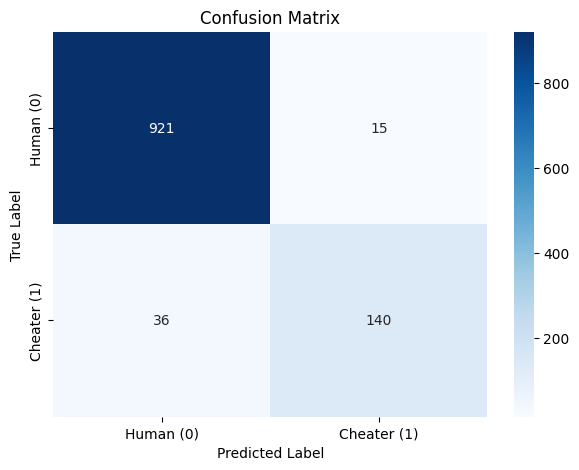


--- 분류 리포트 (Classification Report) ---
              precision    recall  f1-score   support

   Human (0)       0.96      0.98      0.97       936
 Cheater (1)       0.90      0.80      0.85       176

    accuracy                           0.95      1112
   macro avg       0.93      0.89      0.91      1112
weighted avg       0.95      0.95      0.95      1112



In [108]:
# --- 정확도 (Accuracy) ---
print("--- 정확도 (Accuracy) ---")
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# --- 혼동 행렬 (Confusion Matrix) ---
print("\n--- 혼동 행렬 (Confusion Matrix) ---")
cm = confusion_matrix(y_val, y_pred)

# Seaborn을 사용한 히트맵 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            # 0: Human, 1: Cheater
            xticklabels=['Human (0)', 'Cheater (1)'],
            yticklabels=['Human (0)', 'Cheater (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- 분류 리포트 (Classification Report) ---
print("\n--- 분류 리포트 (Classification Report) ---")
# 정밀도(Precision), 재현율(Recall), F1-Score 등을 한 번에 보여줌
report = classification_report(y_val, y_pred, target_names=['Human (0)', 'Cheater (1)'])
print(report)


--- ROC-AUC 점수 및 곡선 ---
ROC-AUC: 0.9878
PR-AUC : 0.9236



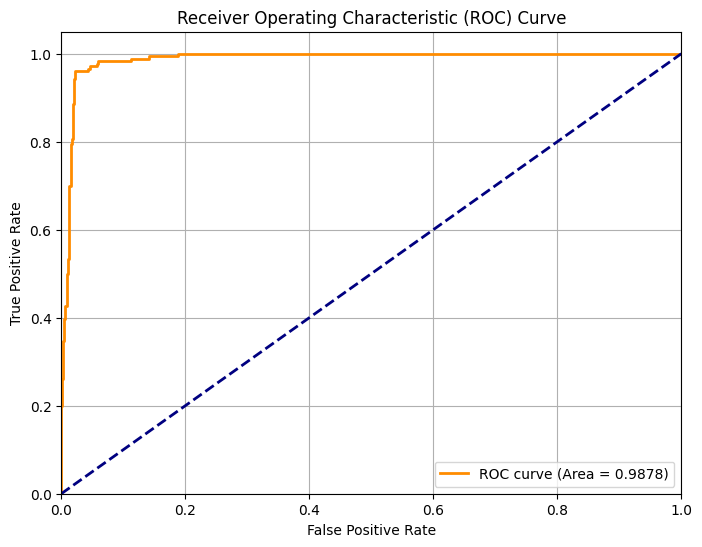

In [109]:
# --- ROC-AUC 점수 및 곡선 ---
print("\n--- ROC-AUC 점수 및 곡선 ---")

# --- ROC-AUC 점수 ---
roc_auc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}\n")

# --- ROC-AUC 곡선 ---
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (Area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 50% 수준의 랜덤 모델
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 게임 이용자 결과 분석

In [110]:
# --- 고유한 파일 이름 리스트에서 랜덤으로 1개 선택 ---
unique_files = df['filename'].unique()
rng = np.random.default_rng(seed=42)
target_filename = rng.choice(unique_files)

# --- 해당 파일에 속하는 '원본 df 기준 인덱스' 리스트 생성 ---
TARGET_INDICES_LIST = df[df['filename'] == target_filename].index.tolist()
num_chunks_in_file = len(TARGET_INDICES_LIST)

# --- 선택된 파일 정보 출력 ---
file_info = df.loc[TARGET_INDICES_LIST[0]] # 첫 번째 청크 정보로 라벨 확인
actual_label = "Cheater (1)" if file_info['cheat'] == 1 else "Human (0)"

print(f"--- 분석할 파일 정보 ---")
print(f"  파일 이름: {target_filename}")
print(f"  총 청크 수: {num_chunks_in_file}")
print(f"  실제 라벨: {actual_label}")
print("-" * 30)
print(f"해당 파일의 청크 인덱스 (X_test_df 기준):")
print(TARGET_INDICES_LIST)

--- 분석할 파일 정보 ---
  파일 이름: cheats/cf504c19-257a-4dbe-a93b-77e139a91646.webm
  총 청크 수: 22
  실제 라벨: Cheater (1)
------------------------------
해당 파일의 청크 인덱스 (X_test_df 기준):
[485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506]


In [111]:
# --- 분석할 청크의 '순번' 지정 ---
CHUNK_ITERATOR_INDEX = 0

# --- 유효성 검사 ---
if 'TARGET_INDICES_LIST' not in locals():
    print("오류: TARGET_INDICES_LIST 변수가 정의되지 않았습니다.")
elif CHUNK_ITERATOR_INDEX >= len(TARGET_INDICES_LIST) or CHUNK_ITERATOR_INDEX < 0:
    print(f"오류: 인덱스 {CHUNK_ITERATOR_INDEX}가 유효하지 않습니다.")
    print(f"유효한 순번(ITERATOR) 범위: 0 ~ {len(TARGET_INDICES_LIST) - 1}")
else:
    # --- 실제 데이터 인덱스 가져오기 ---
    # 리스트에서 '순번'에 해당하는 '실제 인덱스'를 조회
    actual_df_index = TARGET_INDICES_LIST[CHUNK_ITERATOR_INDEX]

    # --- 해당 청크 정보 확인 ---
    selected_chunk_info = df.loc[actual_df_index]
    selected_start_frame = selected_chunk_info['start_frame']

    print(f"--- 분석할 청크 정보 ---")
    print(f"  파일 이름: {target_filename}")
    print(f"  청크 순서: {CHUNK_ITERATOR_INDEX}번째")
    print(f"  실제 인덱스: {actual_df_index}")
    print(f"  시작 프레임: {selected_start_frame}")
    print("-" * 30)

    # --- SHAP Explanation 객체 생성 ---
    # '전체' shap_values에서 'actual_df_index'번째 값만 사용
    explanation_chunk_cheat = shap.Explanation(
        values=shap_values[actual_df_index],
        base_values=expected_value,
        data=X_test_df.iloc[actual_df_index],
        feature_names=X_test_df.columns
    )

--- 분석할 청크 정보 ---
  파일 이름: cheats/cf504c19-257a-4dbe-a93b-77e139a91646.webm
  청크 순서: 0번째
  실제 인덱스: 485
  시작 프레임: 0
------------------------------


In [112]:
# --- 고유한 파일 이름 리스트에서 랜덤으로 1개 선택 ---
unique_files = df['filename'].unique()
rng = np.random.default_rng(seed=80)
target_filename = rng.choice(unique_files)

# --- 해당 파일에 속하는 '원본 df 기준 인덱스' 리스트 생성 ---
TARGET_INDICES_LIST = df[df['filename'] == target_filename].index.tolist()
num_chunks_in_file = len(TARGET_INDICES_LIST)

# --- 선택된 파일 정보 출력 ---
file_info = df.loc[TARGET_INDICES_LIST[0]] # 첫 번째 청크 정보로 라벨 확인
actual_label = "Cheater (1)" if file_info['cheat'] == 1 else "Human (0)"

print(f"--- 분석할 파일 정보 ---")
print(f"  파일 이름: {target_filename}")
print(f"  총 청크 수: {num_chunks_in_file}")
print(f"  실제 라벨: {actual_label}")
print("-" * 30)
print(f"해당 파일의 청크 인덱스 (X_test_df 기준):")
print(TARGET_INDICES_LIST)

--- 분석할 파일 정보 ---
  파일 이름: videos/e7d4aec4-9798-4d99-bb62-044f1c868d2c.webm
  총 청크 수: 22
  실제 라벨: Human (0)
------------------------------
해당 파일의 청크 인덱스 (X_test_df 기준):
[5039, 5040, 5041, 5042, 5043, 5044, 5045, 5046, 5047, 5048, 5049, 5050, 5051, 5052, 5053, 5054, 5055, 5056, 5057, 5058, 5059, 5060]


In [113]:
# --- 분석할 청크의 '순번' 지정 ---
CHUNK_ITERATOR_INDEX = 0

# --- 유효성 검사 ---
if 'TARGET_INDICES_LIST' not in locals():
    print("오류: TARGET_INDICES_LIST 변수가 정의되지 않았습니다.")
elif CHUNK_ITERATOR_INDEX >= len(TARGET_INDICES_LIST) or CHUNK_ITERATOR_INDEX < 0:
    print(f"오류: 인덱스 {CHUNK_ITERATOR_INDEX}가 유효하지 않습니다.")
    print(f"유효한 순번(ITERATOR) 범위: 0 ~ {len(TARGET_INDICES_LIST) - 1}")
else:
    # --- 실제 데이터 인덱스 가져오기 ---
    # 리스트에서 '순번'에 해당하는 '실제 인덱스'를 조회
    actual_df_index = TARGET_INDICES_LIST[CHUNK_ITERATOR_INDEX]

    # --- 해당 청크 정보 확인 ---
    selected_chunk_info = df.loc[actual_df_index]
    selected_start_frame = selected_chunk_info['start_frame']

    print(f"--- 분석할 청크 정보 ---")
    print(f"  파일 이름: {target_filename}")
    print(f"  청크 순서: {CHUNK_ITERATOR_INDEX}번째")
    print(f"  실제 인덱스: {actual_df_index}")
    print(f"  시작 프레임: {selected_start_frame}")
    print("-" * 30)

    # --- SHAP Explanation 객체 생성 ---
    # '전체' shap_values에서 'actual_df_index'번째 값만 사용
    explanation_chunk_human = shap.Explanation(
        values=shap_values[actual_df_index],
        base_values=expected_value,
        data=X_test_df.iloc[actual_df_index],
        feature_names=X_test_df.columns
    )

--- 분석할 청크 정보 ---
  파일 이름: videos/e7d4aec4-9798-4d99-bb62-044f1c868d2c.webm
  청크 순서: 0번째
  실제 인덱스: 5039
  시작 프레임: 0
------------------------------


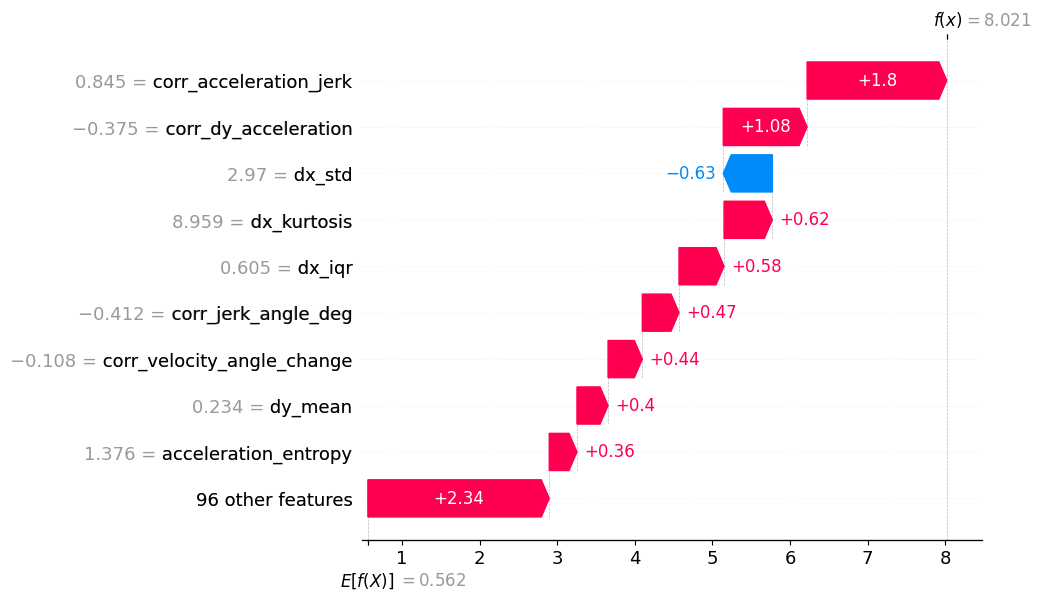

In [114]:
# --- Waterfall Plot ---
shap.plots.waterfall(explanation_chunk_cheat)
plt.show()

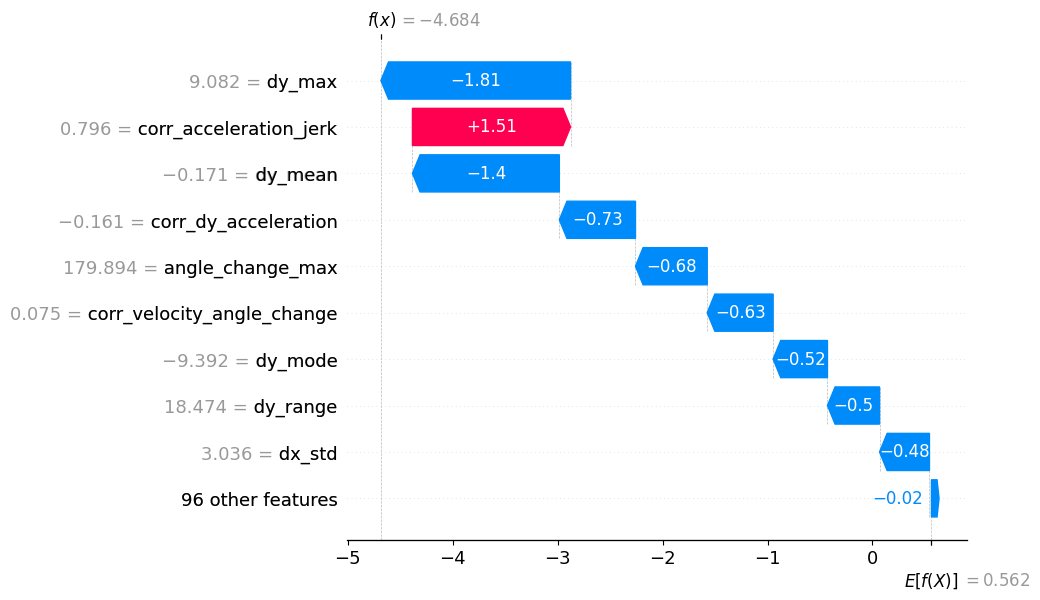

In [115]:
# --- Waterfall Plot ---
shap.plots.waterfall(explanation_chunk_human)
plt.show()

## 모델 전체 경향성 분석

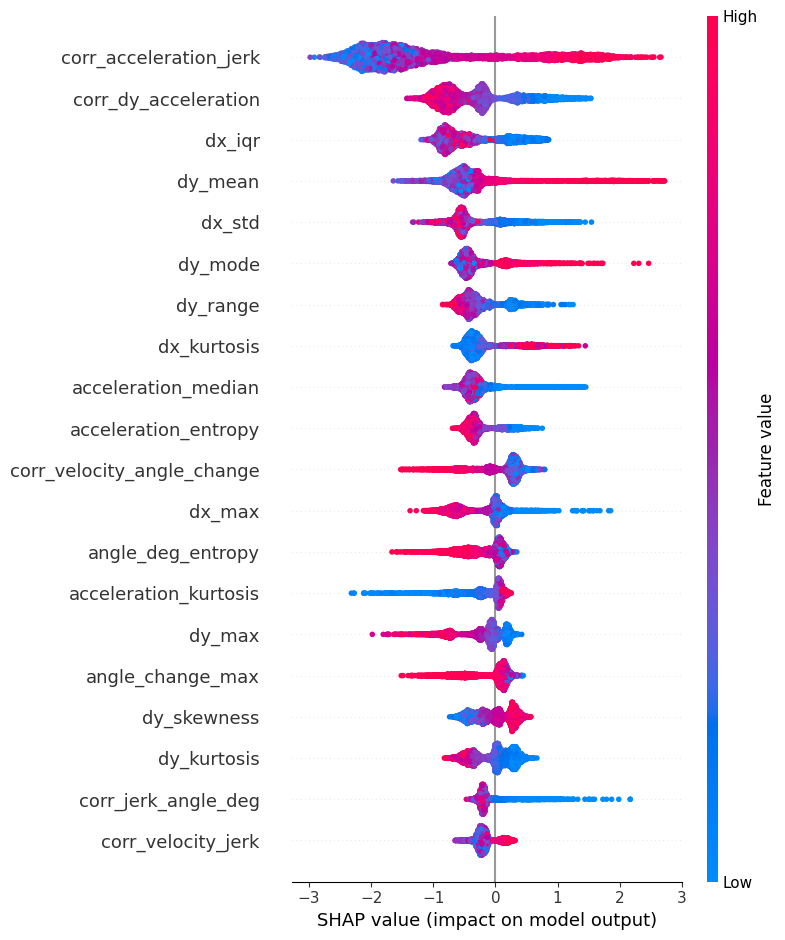

In [116]:
# --- 모델 전체 경향성 분석 ---
shap.summary_plot(shap_values, X_test_df)
plt.show()

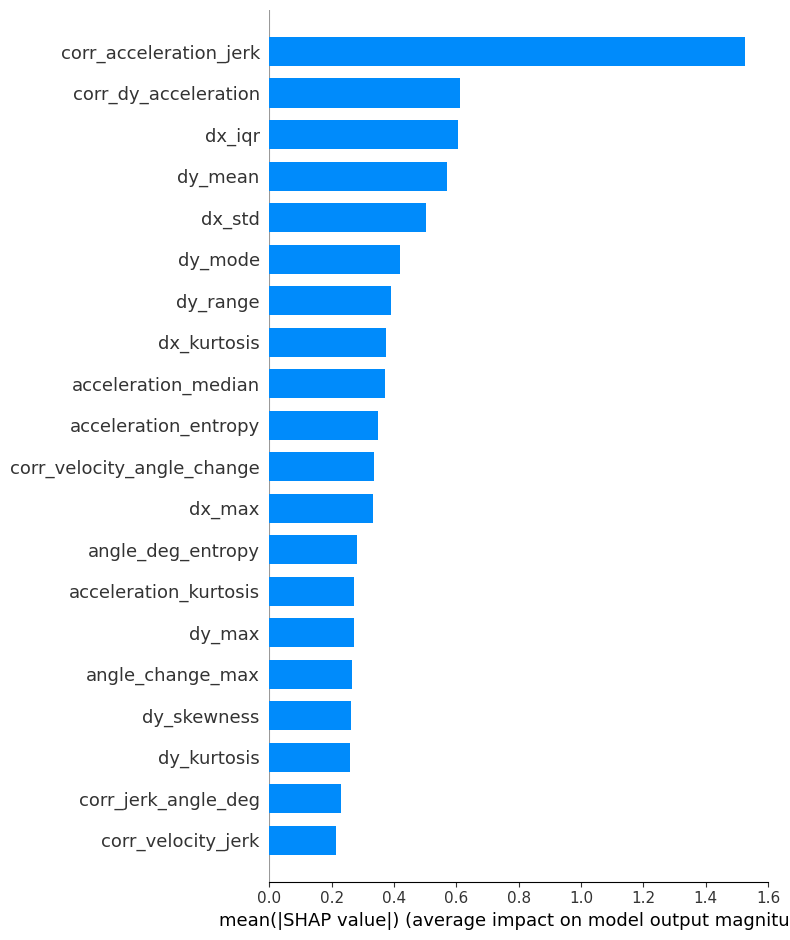

In [117]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar")
plt.show()

In [118]:
# JavaScript 시각화를 위해 초기화 (Colab에서 필수)
shap.initjs()

# --- 모든 샘플에 대한 Force Plot ---
# 너무 많으므로 1000개만 샘플링하여 시각화
force_plot_html = shap.force_plot(
    expected_value,
    shap_values[0:1000],
    X_test_df.iloc[0:1000]
)

# 노트북에 바로 표시 (샘플링 버전)
force_plot_html

# 결론

---

1.  **주요 성과**:
    * 플레이 영상만으로 치터 탐지 가능성을 확인
    * AI 모델의 판단 근거를 시각화
2.  **프로젝트 의의**:
    * 기존에 탐지할 수 없는 AI 기반 치트에 대응하는 안티 치트 시스템을 구현
    * 높은 정확도와 설명 가능한 AI를 통한 투명하고 신뢰성 있는 AI 모델을 구현
3.  **향후 과제**:
    * 다양한 환경의 데이터를 확보하여 범용성 높은 모델로의 확장
    * 다른 안티 치트 프로그램과의 조합을 통한 더 신뢰성 높은 시스템으로의 확장
    * 모델 경량화 및 파이프라인 최적화를 통한 실시간 탐지 시스템으로의 확장